# LoCoMo QA accuracy (LLM-judged)

A harder benchmark than evidence-retrieval MRR: for each question, each
system answers *from its own retrieved top-10 turns*, and a Codex judge
scores the answer against the gold answer. This is the answer-accuracy
metric the mem0 / Zep LoCoMo papers report — it tests whether retrieved
memory is actually sufficient to answer, not just whether the gold
evidence ranked highly. Retrieval is the frozen, comparable measurement;
the QA layer is applied identically to all three systems.

Data: `evals/notebooks/data/locomo_qa_accuracy_2026-06-11.json`. Stratified
sample of 50 questions/category (seed 42), categories 1-4 (the adversarial
category 5 is excluded). 95% intervals are Wilson score intervals.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
from memd_plotting import (apply_house_style, color_for, load_json, DISPLAY_NAME,
                            LOCOMO_CATEGORY, figures_dir)
apply_house_style()
FIG = figures_dir()
qa = load_json('data/locomo_qa_accuracy_2026-06-11.json')
order = ['memd', 'mem0', 'superlocalmemory']
systems = sorted(qa['systems'].items(), key=lambda kv: order.index(kv[0]) if kv[0] in order else 99)
[(k, round(v['accuracy'], 3)) for k, v in systems]

[('memd', 0.435), ('mem0', 0.385), ('superlocalmemory', 0.38)]

## Figure 1 — overall QA accuracy with 95% CIs

memd leads on the harder end-to-end metric, consistent with its retrieval
lead. At this 200-question sample the Wilson intervals overlap, so the QA
gap is directional — it corroborates the retrieval ranking rather than
separating the systems on its own.

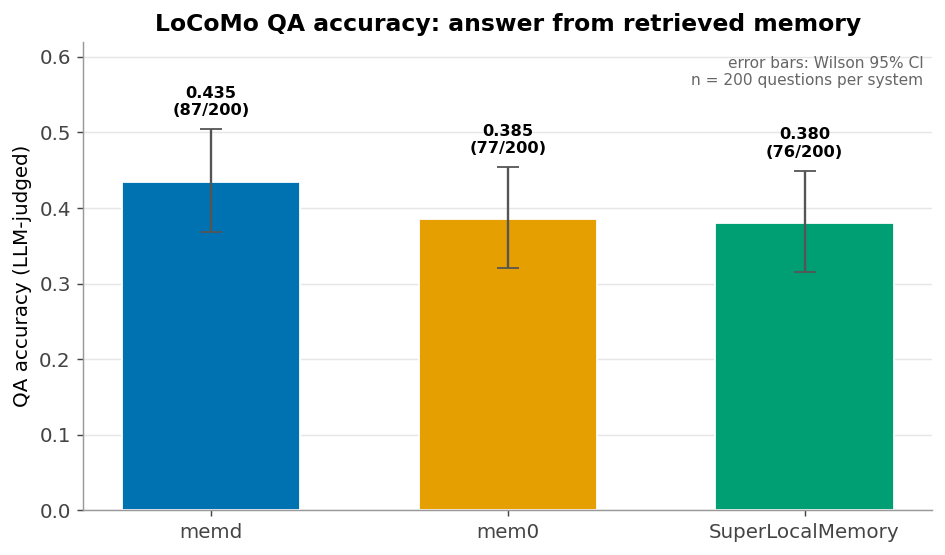

In [2]:
names = [DISPLAY_NAME.get(k, k) for k, _ in systems]
accs = [v['accuracy'] for _, v in systems]
los = [v['accuracy'] - v['ci_lower'] for _, v in systems]
his = [v['ci_upper'] - v['accuracy'] for _, v in systems]
colors = [color_for(k) for k, _ in systems]
fig, ax = plt.subplots(figsize=(7.4, 4.4))
bars = ax.bar(range(len(systems)), accs, width=0.6, color=colors,
              yerr=[los, his], capsize=6, edgecolor='white',
              error_kw={'ecolor': '#555555', 'lw': 1.3})
ax.set_xticks(range(len(systems)))
ax.set_xticklabels(names)
ax.set_ylabel('QA accuracy (LLM-judged)')
ax.set_ylim(0, 0.62)
ax.set_title('LoCoMo QA accuracy: answer from retrieved memory')
ax.grid(axis='x', visible=False)
# Place each label just above that bar's own CI cap (not a shared offset).
for bar, (_, v) in zip(bars, systems):
    ax.text(bar.get_x() + bar.get_width()/2, v['ci_upper'] + 0.015,
            f"{v['accuracy']:.3f}\n({v['correct']}/{v['n']})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.text(0.99, 0.97, 'error bars: Wilson 95% CI\nn = 200 questions per system',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#666666')
fig.tight_layout()
fig.savefig(FIG / 'locomo_qa_accuracy.png')
fig.savefig(FIG / 'locomo_qa_accuracy.svg')
plt.show()

## Figure 2 — QA accuracy by question category

The category picture is mixed: memd leads multi-hop (cat 1) and temporal
(cat 2); SuperLocalMemory edges single-hop long-form (cat 4); the small
open-domain set (cat 3) is hardest for every system.

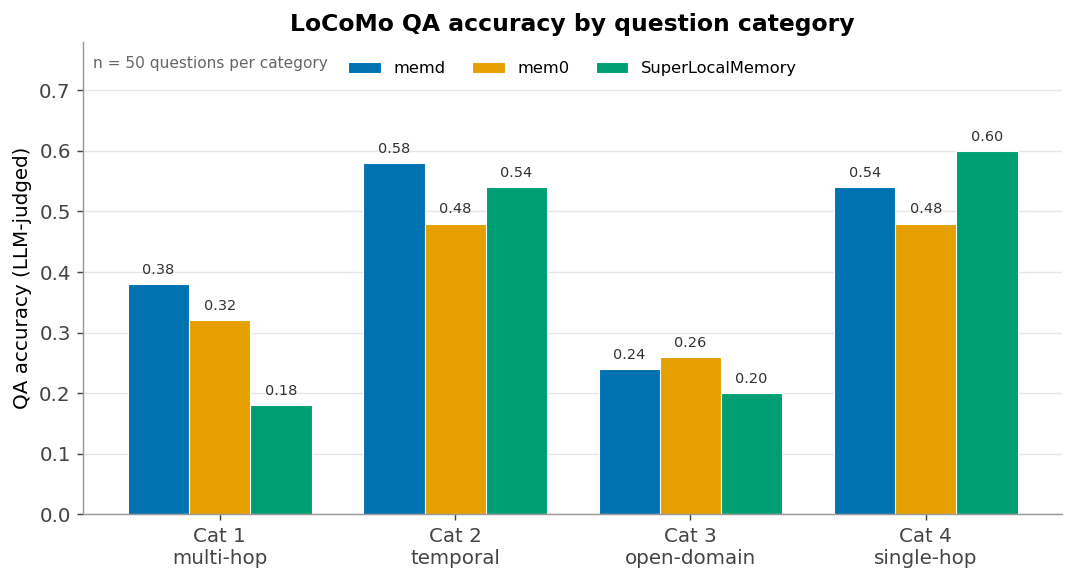

In [3]:
cats = sorted({c for _, v in systems for c in v['per_category']})
x = np.arange(len(cats))
w = 0.78 / len(systems)
fig, ax = plt.subplots(figsize=(8.4, 4.6))
for i, (k, v) in enumerate(systems):
    vals = [v['per_category'].get(c, {}).get('accuracy', 0) for c in cats]
    offset = (i - (len(systems) - 1) / 2) * w
    bars = ax.bar(x + offset, vals, width=w, color=color_for(k),
                  label=DISPLAY_NAME.get(k, k), edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.012, f'{val:.2f}',
                ha='center', va='bottom', fontsize=8, color='#333333')
ax.set_xticks(x)
ax.set_xticklabels([f'Cat {c}\n{LOCOMO_CATEGORY.get(c, "?")}' for c in cats])
ax.set_ylabel('QA accuracy (LLM-judged)')
# Headroom for the single-row legend above the tallest bars (0.60).
ax.set_ylim(0, 0.78)
ax.set_title('LoCoMo QA accuracy by question category')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=3, fontsize=9,
          frameon=False, columnspacing=1.6)
ax.grid(axis='x', visible=False)
ax.text(0.01, 0.97, 'n = 50 questions per category',
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#666666')
fig.tight_layout()
fig.savefig(FIG / 'locomo_qa_accuracy_per_category.png')
fig.savefig(FIG / 'locomo_qa_accuracy_per_category.svg')
plt.show()